FileNotFoundError: [Errno 2] No such file or directory: '../runs/shap_baseline/shap_summary_baseline.png'

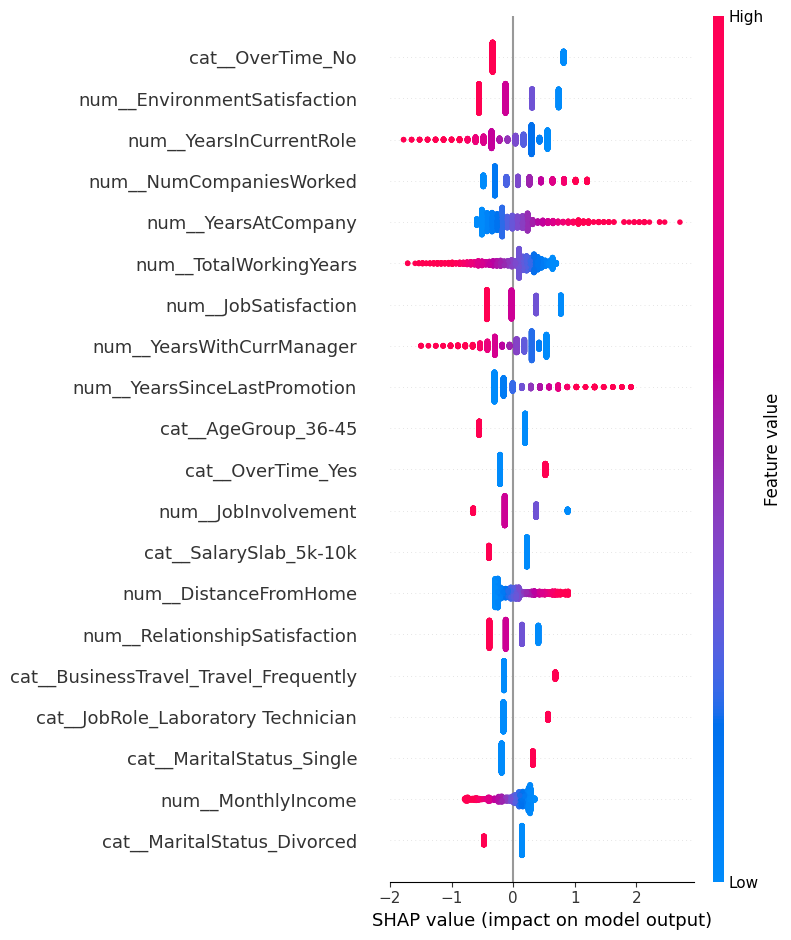

In [5]:
import sys
from pathlib import Path
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


output_dir = Path("../runs/shap_baseline")
output_dir.mkdir(parents=True, exist_ok=True)

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data.loader import load_hr_analytics
from src.models.baseline import get_logistic_regression_pipeline




ds = load_hr_analytics("../data/raw/HR_Analytics.csv")

pipeline = get_logistic_regression_pipeline(ds.X)
pipeline.fit(ds.X, ds.y)

preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

X_processed = preprocessor.transform(ds.X)

X_processed = X_processed.toarray()

explainer = shap.Explainer(
    model,
    X_processed,
    feature_names=preprocessor.get_feature_names_out()
)

shap_values = explainer(X_processed)

shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=preprocessor.get_feature_names_out(),
    show=False
)

plt.tight_layout()
plt.savefig("../runs/shap_baseline/shap_summary_baseline.png", dpi=300)
plt.close()

preds = pipeline.predict(ds.X)
positive_idx = np.where(preds == 1)[0][0]
negative_idx = np.where(preds == 0)[0][0]

for idx, name in [(positive_idx, "positive"), (negative_idx, "negative")]:
    shap.plots.waterfall(
        shap_values[idx],
        show=False
    )
    plt.tight_layout()
    plt.savefig(f"../runs/shap_baseline/shap_local_{name}.png", dpi=300)
    plt.close()


